# Comparison of Placement Algorithms

This notebook compares the performance metrics (latency and network usage) between two YAFS placement algorithms:
1. **Latency-based (Baseline)**
2. **Custom Proposed Strategy**

The analysis uses simulation trace data generated by YAFS.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [56]:
# Define file paths
results_dir = 'resultados'

# Latency Strategy Files
latency_trace_file = os.path.join(results_dir, '5-latency-sim_trace.csv')
latency_link_file = os.path.join(results_dir, '5-latency-sim_trace_link.csv')

# Custom Strategy Files
custom_trace_file = os.path.join(results_dir, '5-custom_proposed_by_felipe-sim_trace.csv')
custom_link_file = os.path.join(results_dir, '5-custom_proposed_by_felipe-sim_trace_link.csv')

# Round Robin Strategy Files
rr_trace_file = os.path.join(results_dir, '5-roundRobin-sim_trace.csv')
rr_link_file = os.path.join(results_dir, '5-roundRobin-sim_trace_link.csv')

# Load DataFrames
df_latency_trace = pd.read_csv(latency_trace_file)
df_latency_link = pd.read_csv(latency_link_file)

df_custom_trace = pd.read_csv(custom_trace_file)
df_custom_link = pd.read_csv(custom_link_file)

df_rr_trace = pd.read_csv(rr_trace_file)
df_rr_link = pd.read_csv(rr_link_file)

print("Data loaded successfully.")
print(f"Latency Trace: {df_latency_trace.shape}")
print(f"Custom Trace: {df_custom_trace.shape}")
print(f"Round Robin Trace: {df_rr_trace.shape}")

Data loaded successfully.
Latency Trace: (25212, 17)
Custom Trace: (23006, 17)
Round Robin Trace: (20207, 17)


In [57]:
# Add Strategy Label
df_latency_trace['Strategy'] = 'Latency (Baseline)'
df_custom_trace['Strategy'] = 'Custom Proposed'
df_rr_trace['Strategy'] = 'Round Robin'

df_latency_link['Strategy'] = 'Latency (Baseline)'
df_custom_link['Strategy'] = 'Custom Proposed'
df_rr_link['Strategy'] = 'Round Robin'

# Combine DataFrames
df_trace_all = pd.concat([df_latency_trace, df_custom_trace, df_rr_trace])
df_link_all = pd.concat([df_latency_link, df_custom_link, df_rr_link])

# Convert Link Wait Time to ms
if 'wait' in df_link_all.columns:
    df_link_all['wait'] = df_link_all['wait'] * 1000

# Filter for End-to-End Latency (Service -> Sensor Response)
# The application flow is Sensor -> Service (M_Req) -> Sensor (M_Resp).
# We analyze the latency of the response message 'M_Resp' as it completes the cycle.
# target_message = 'M_Resp'
df_results = df_trace_all #[df_trace_all['message'] == target_message].copy()

if df_results.empty:
    print(f"WARNING: No messages found with name '{target_message}'. Check your simulation code.")
else:
    # Calculate Latency (Convert to ms)
    df_results['latency'] = df_results['service'] * 1000

    print("Combined Data:")
    print(df_results[['Strategy', 'latency']].head())

Combined Data:
             Strategy    latency
0  Latency (Baseline)  34.207253
1  Latency (Baseline)  41.478276
2  Latency (Baseline)  31.923809
3  Latency (Baseline)  21.767918
4  Latency (Baseline)  37.752994


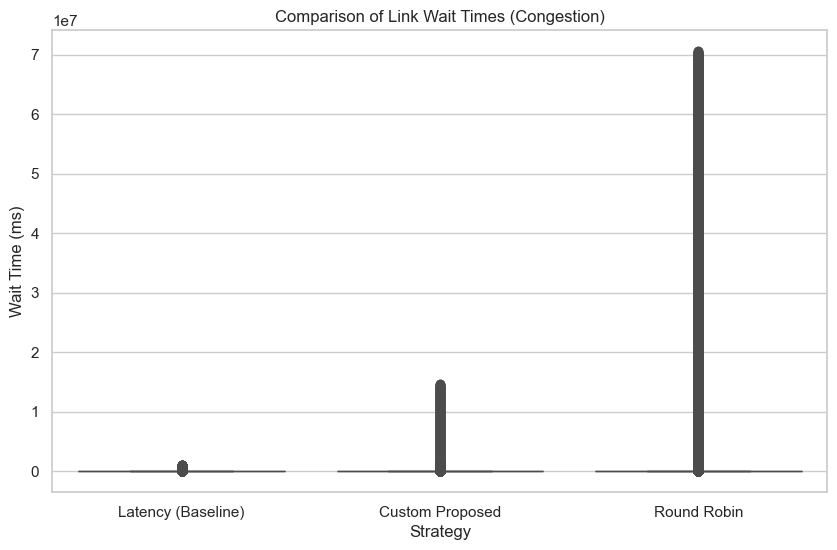

Link Wait Time Statistics:


,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
Custom Proposed,79086.0,49063.335325,4.705845e+05,0.0,0.0,0.0,16.334726,1.467953e+07
Latency (Baseline),80258.0,17105.702858,6.669836e+04,0.0,0.0,0.0,12.007646,1.009966e+06
Round Robin,85535.0,991360.499931,6.108598e+06,0.0,0.0,0.0,2810.373853,7.056381e+07


In [58]:
# Compare Link Wait Times
if 'wait' in df_link_all.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Strategy', y='wait', data=df_link_all)
    plt.title('Comparison of Link Wait Times (Congestion)')
    plt.ylabel('Wait Time (ms)')
    plt.show()
    
    # Summary stats for wait time
    print("Link Wait Time Statistics:")
    display(df_link_all.groupby('Strategy')['wait'].describe())
else:
    print("Wait time column not found in link traces.")

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_17386/2599439816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")


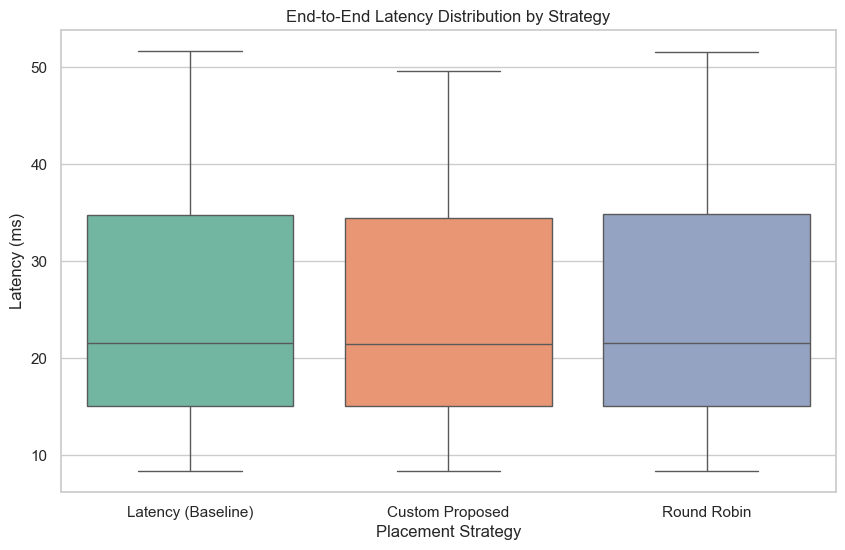

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_17386/2599439816.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")


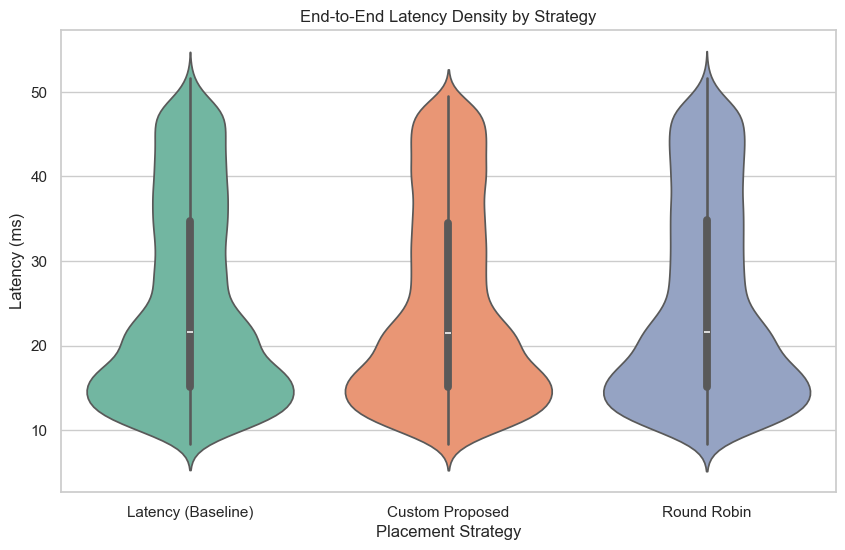

In [59]:
# Visualize Latency Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Distribution by Strategy')
plt.ylabel('Latency (ms)')
plt.xlabel('Placement Strategy')
plt.show()

# Violin Plot for density
plt.figure(figsize=(10, 6))
sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Density by Strategy')
plt.ylabel('Latency (ms)')
plt.xlabel('Placement Strategy')
plt.show()

             Strategy  Total Data Transferred (MB)
0     Custom Proposed                   113.066126
1  Latency (Baseline)                   114.660346
2         Round Robin                   122.580858


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_17386/2078876125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Total Data Transferred (MB)', data=network_usage, palette="viridis")


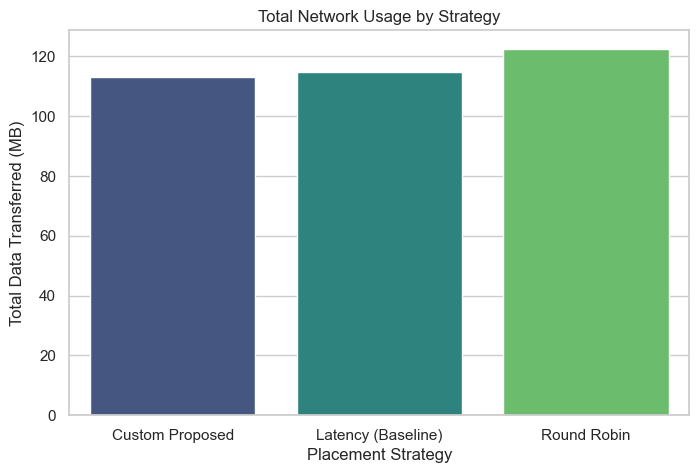

In [60]:
# Calculate Total Network Usage (Bytes Transferred)
network_usage = df_link_all.groupby('Strategy')['size'].sum().reset_index()
network_usage.columns = ['Strategy', 'Total Bytes']

# Convert to MB
network_usage['Total Data Transferred (MB)'] = network_usage['Total Bytes'] / (1024 * 1024)

print(network_usage[['Strategy', 'Total Data Transferred (MB)']])

# Visualize Network Usage
plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Total Data Transferred (MB)', data=network_usage, palette="viridis")
plt.title('Total Network Usage by Strategy')
plt.ylabel('Total Data Transferred (MB)')
plt.xlabel('Placement Strategy')
plt.show()

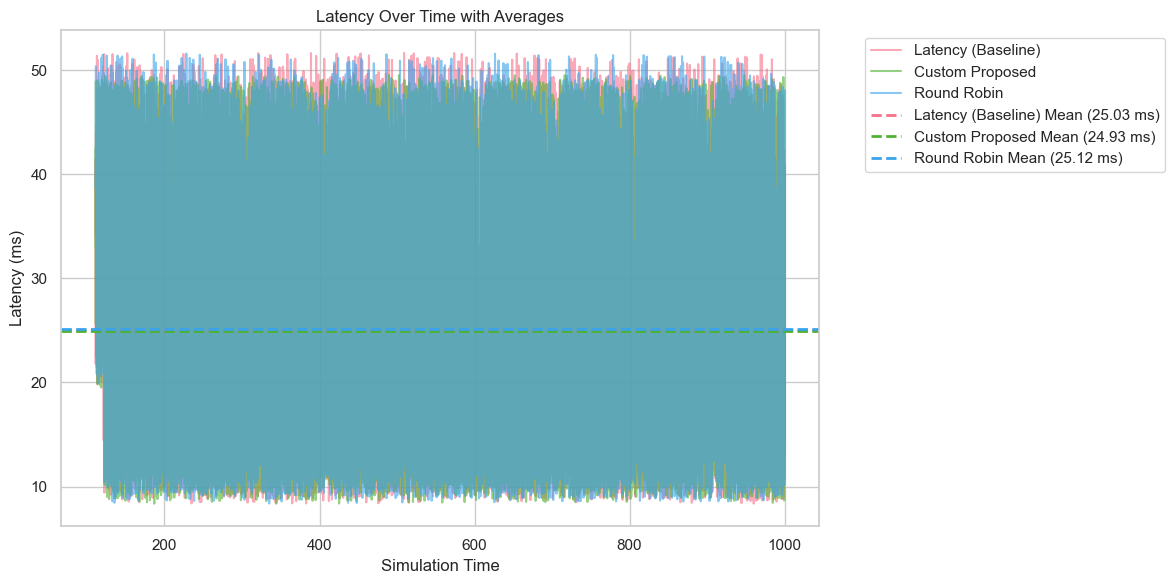

In [61]:
# Latency Over Time with Averages
plt.figure(figsize=(12, 6))

# Define a palette to ensure consistent colors
strategies = df_results['Strategy'].unique()
palette = sns.color_palette("husl", len(strategies))
strategy_colors = dict(zip(strategies, palette))

# Plot Latency over Time
sns.lineplot(x='time_reception', y='latency', hue='Strategy', data=df_results, alpha=0.6, palette=strategy_colors)

# Calculate and plot averages
for strategy in strategies:
    mean_val = df_results[df_results['Strategy'] == strategy]['latency'].mean()
    color = strategy_colors[strategy]
    plt.axhline(y=mean_val, color=color, linestyle='--', linewidth=2, label=f'{strategy} Mean ({mean_val:.2f} ms)')

plt.title('Latency Over Time with Averages')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
# Summary Statistics
summary_stats = df_results.groupby('Strategy')['latency'].agg(['mean', 'min', 'max', 'std', 'count']).reset_index()
summary_stats = summary_stats.merge(network_usage, on='Strategy')

print("Summary Statistics Table:")
display(summary_stats)

Summary Statistics Table:


,Strategy,mean,min,max,std,count,Total Bytes,Total Data Transferred (MB)
0,Custom Proposed,24.932100,8.348208,49.554097,11.557308,23006,118558426,113.066126
1,Latency (Baseline),25.032687,8.354992,51.647583,11.687208,25212,120230087,114.660346
2,Round Robin,25.115431,8.369617,51.583530,11.734211,20207,128535346,122.580858


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_17386/3521826341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")


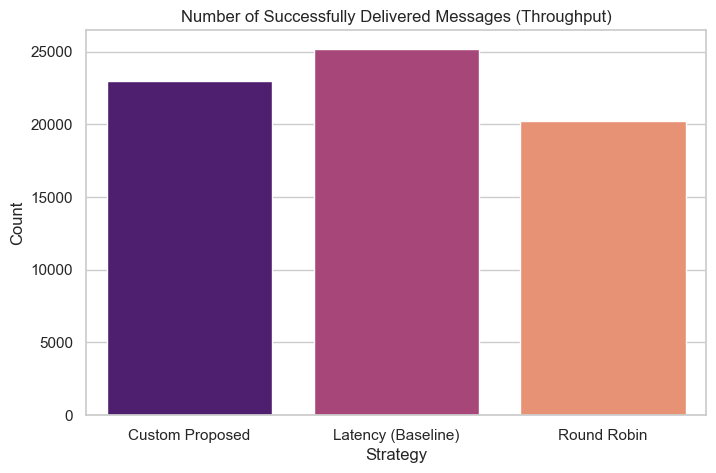

Message Delivery Counts:


,Strategy,Delivered Messages
0,Custom Proposed,23006
1,Latency (Baseline),25212
2,Round Robin,20207


In [63]:
# Visualize Message Delivery Count (Throughput)
message_counts = df_results.groupby('Strategy').size().reset_index(name='Delivered Messages')

plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")
plt.title('Number of Successfully Delivered Messages (Throughput)')
plt.ylabel('Count')
plt.show()

print("Message Delivery Counts:")
display(message_counts)
